# T08 - Pseudo Random Number Generator (PRNG)

## Objective
Design and implement a pseudo-random number generator (PRNG) on the **CMOD A7 FPGA board** using Verilog. The generated number shall be displayed on the 4-digit 7-segment LED display, with features for reset, seeding, and periodic updates.

---

## Key Features
1. **Reset Functionality**  
   - Press **BTN0** to restart the system and generate a new seed.
   
2. **7-Segment Display**  
   - Display the pseudo-random number in decimal (e.g., `3271`) or hexadecimal (e.g., `3ab1`).  
   - First number after reset must be validated using an external seed source:  
     - Ambient temperature  
     - Ambient light intensity  
     - Thermal noise from resistor  
     - Real-time clock  
     - *Additional remarks awarded for creative seeding approaches*  

3. **Update Frequency**  
   - Refresh the displayed number at a configurable interval (e.g., 1 second).  

---

## Instructions

### FPGA Project Setup
1. **Vivado Project**  
   - Create a new Vivado project targeting the **CMOD A7-35T** FPGA.  

2. **Verilog Implementation**  
   - Design the PRNG core using a linear feedback shift register (LFSR) or other algorithm.  

3. **Testbench (Optional)**  
   - Verify PRNG output distribution (e.g., Gaussian) using statistical tests.  

4. **Constraint File (.xdc)**  
   - Map I/O pins for buttons, clock, and 7-segment display.  

5. **Bitstream Generation & Programming**  
   - Synthesize the design and program the FPGA.  

6. **Testing & Documentation**  
   - Debug using onboard LEDs and document challenges, state diagrams, and design choices.  

---

## Submission Requirements
1. **Jupyter Notebook (`T08_PRNG.ipynb`)**  
   - Include:  
     - **Verilog Code** (modules, testbenches, waveforms).  
     - **Demo Video** (≤1 minute, MP4 format).  
     - **Report** with design rationale, challenges, and lessons learned.  

2. **Additional Files**  
   - Submit `.ipynb` and video to edimension.  

---

## Challenges
1. **Application Project**  
   - Implement a real-world application (e.g., lottery system, game).  

2. **Algorithmic Project**  
   - Develop a novel PRNG variant (e.g., combining LFSR with chaos theory).  

3. **Theoretical Project**  
   - Analyze PRNG properties (e.g., entropy, periodicity).  

4. **True Random Number Generator**

*Contact the faculty and researchers for customized project ideas.*

---

## Deadline & Grading
- **Deadline**: Set in the edimension submission folder.  
- **Grading Criteria**:  
  - Innovativeness.
  - Educational values.  
  - *Bonus points for creative implementations.*  
- The report should present how AI is used in the design (if applicable).
---



---

# Start your handson's report from this line

(Complete the report, save this ipynb, and submit in edimention)

---

## Group No.:

Member name:
1. Logavarshini Kandaraj    
2. Ho Yong Zhan Vincent 
3. He Jia Xuan Jeremiah  
4. Rey Lam Lai Yan   
5. Kulkarni Ojas Jaydeep        

---

Verilog Code - Module

Verilog Code - XDC File

In [ ]:
##==========================================================
## CMOD A7-35T Constraints for UART Seeded LFSR_NL
##==========================================================

## Clock signal (12 MHz onboard oscillator)
set_property -dict { PACKAGE_PIN L17   IOSTANDARD LVCMOS33 } [get_ports { sysclk }];
create_clock -add -name sys_clk_pin -period 83.33 -waveform {0 41.66} [get_ports { sysclk }];

## UART pins on DIP connector
## DIP pin 22 - UART TX from FPGA
set_property -dict { PACKAGE_PIN W19   IOSTANDARD LVCMOS33 } [get_ports { uart_tx }];

## DIP pin 23 - UART RX to FPGA
set_property -dict { PACKAGE_PIN V19   IOSTANDARD LVCMOS33 } [get_ports { uart_rx }];

## Optional LEDs for status
set_property -dict { PACKAGE_PIN A17   IOSTANDARD LVCMOS33 } [get_ports { led[0] }];
set_property -dict { PACKAGE_PIN C16   IOSTANDARD LVCMOS33 } [get_ports { led[1] }];

## Configuration options
set_property BITSTREAM.GENERAL.COMPRESS TRUE [current_design]
set_property BITSTREAM.CONFIG.SPI_BUSWIDTH 4 [current_design]
set_property CONFIG_VOLTAGE 3.3 [current_design]
set_property CFGBVS VCCO [current_design]


TestBench File

In [ ]:
`timescale 1ns / 1ps

module tb_lfsr();
    reg sysclk;
    reg [1:0] SW;
    reg [1:0] btn;
    wire [5:0] HEX;
    wire [6:0] SEG;
    wire [1:0] led;
    wire tx;

    // Instantiate your TRNG module
    lfsr_nl_modified_von_1_3M_V3 uut (
        .sysclk(sysclk), .SW(SW), .btn(btn),
        .HEX(HEX), .SEG(SEG), .led(led), .tx(tx)
    );

    // Generate 12MHz Clock
    initial sysclk = 0;
    always #41.66 sysclk = ~sysclk;

    initial begin
        // 1. Start in Reset
        SW = 2'b10; btn = 2'b00;
        #200;
        
        // 2. Release Reset & Enable
        SW = 2'b01; 
        #5000; // Run for a bit to see the LFSR shift
        
        $finish;
    end
endmodule

In [ ]:
Waveform Photo

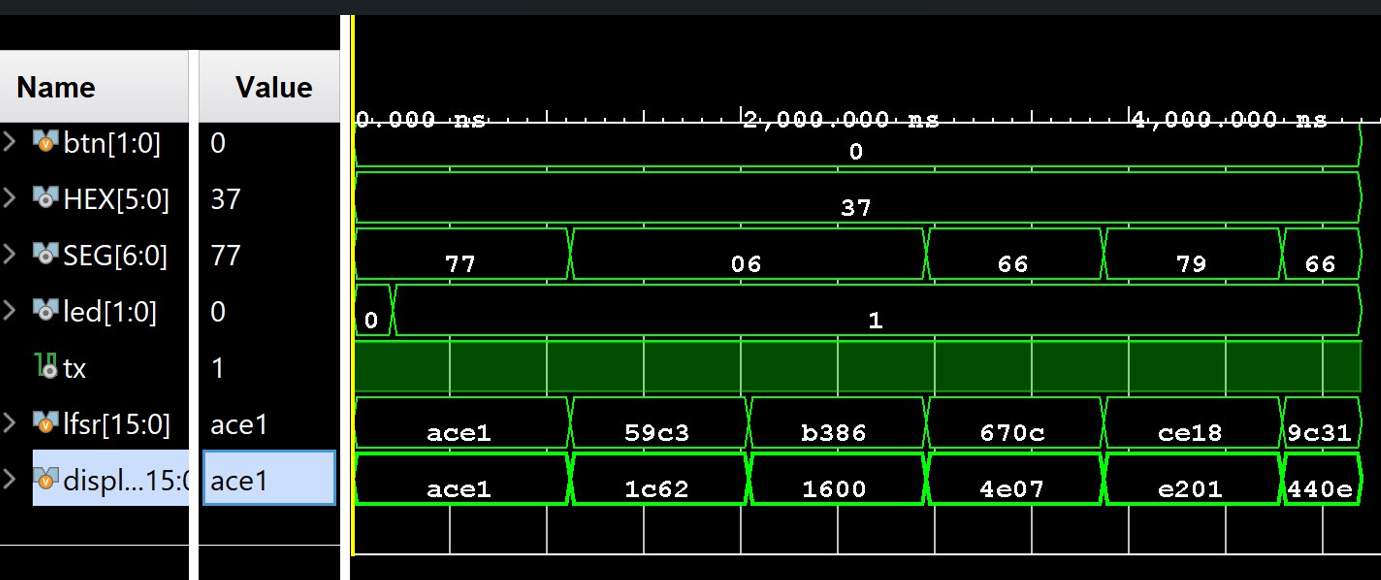

Video Link - https://www.youtube.com/watch?v=fUEfG1KX0vk

In [ ]:
Report 

http://172.18.240.34:8000/hub/user-redirect/lab/tree/Group4_Report.pdf

In [ ]:
Group4_Report.pdf